## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Mahati Vedula

**Date:** 09/30/2026

**Q1**
1. What is the difference between regression and classification?
- Both regression and classification are methods of predicting outcomes (a target variable) for an observation. However, regression deals with predicting quantitative/numerical outputs, whereas classification predicts qualitative/categorical outputs. For example, regression can help predict the PRICE of a diamond based on its characteristics, whereas classification can help predict the BREED of dog based on its attributes.
2. What is a confusion table? What does it help us understand about a model's performance?
- A confusion table has actual values as rows and the model's prediction values as columns, and counts the number of data points predicted correctly and incorrectly within the matrix (the diagonal is correct predictions). For example, if the model predicts "yes" and the actual value is "no," it is a false positive. When the model predicts "no" and the true value is "yes," it is a false negative. When the model predicts the actual values correctly (yes/yes or no/no) these are true positives and true negatives. A confusion table helps us understand the accuracy of a classification model by comparing false positive/negative counts with true positive/negative counts.
3. What does the SSE quantify about a particular model?
- The Sum of Squared Error (SSE) helps quantify how well the model fits the validation data when it is tested. The SSE is sensitive to large errors (since it involves squaring the residuals) so a high SSE means that the model does not represent the data or the situation very well and has less predictive power.
4. What are overfitting and underfitting?
- Overfitting refers to creating a model that fits the training data so well that it takes into account all the noise and outliers. When the model is tested against the testing data, it performs poorly because it is so tailored to the training data that it cannot be generalized across other contexts. This can happen if the k-value is too high becuase the algorithm will focus on immediate near neighbors and ignore more broad data patterns. Underfitting is the opposite; this occurs when the algorithm is so general that no meaningful conclusions can be drawn from it. An underfitted model also performs poorly on testing data because it fails to capture nuances and patterns in the data. A low k-value can cause underfitting because it produces clusters that are too large.
5. Why does splitting the data into training and testing sets, and choosing  𝑘  by evaluating accuracy or SSE on the test set, improve model performance?
- Splitting the data into training and testing sets is important because it allows us to create the model AND test the model's performance on the same dataset that it was trained on to see if its accuracy carries over. Additionally, it's common practice to split large datasets 80/20 for testing/training rather than a 50/50. This is because using the majority of data to train helps create a better model, while fewer data are needed to evaluate the performance. Another important consideration is choosing the right k-value, which is done by evaluating the accuracy of the outputs. For categorical data, this is done by measuring the proportion of false positives and negatives to total predictions. For numerical outputs, this is done by calculating how large the SSE is. The k-value is adjusted accordinging to minimize false predictions and SSE.
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.
- Reporting a data point with a class label prediction allows us to form definitive clusters and make predictions. This is simpler to interpret, but the downside is that there may be incorrect labels because the model has to assign a label when some data points might fit reasonably into multiple categories (e.g. a model will report "yes" even if the probability of "yes" vs "no" is only 60%). With a probability distribution, the upside is that the model outputs the chance of each class label, allowing the level of certainty of the output to be visible; this addresses the problem of nuance mentioned earlier. However, the downside of a probability is that it is more difficult to interpet and there are no black and white class labels assigned.

**Q2**

In [43]:
import pandas as pd
import numpy as np
import sklearn

# Step 1: Loading data, performing EDA, and summarizing target label and features
df = pd.read_csv('data/land_mines.csv')
print(df.shape, '\n')
print(df.dtypes, '\n')
print(df.head(n=15).to_string(), '\n')
print(df.describe().to_string(), '\n')

# Step 2: Split data into training and testing
eval_X_raw = df[['voltage', 'height', 'soil']]
eval_y = df['mine_type']

(
    eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid
) = sklearn.model_selection.train_test_split(
    eval_X_raw, eval_y, test_size = 0.5, random_state = 65)
eval_scaler = sklearn.preprocessing.MinMaxScaler()
# scales the training and validation data to be between 0 and 1
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)

# Step 3: Build a knn classifier
eval_ks = np.arange(1, 19)
eval_valid_error = []
eval_train_error = []

for eval_k in eval_ks:
    eval_candidate = sklearn.neighbors.KNeighborsClassifier(n_neighbors = int(eval_k))
    eval_candidate.fit(eval_X_train_scaled, eval_y_train)
    eval_valid_hat = eval_candidate.predict(eval_X_valid_scaled)
    eval_train_hat = eval_candidate.predict(eval_X_train_scaled)
    # compute the mean error for the validation and training sets
    eval_valid_error.append(np.mean(eval_y_valid.to_numpy() != eval_valid_hat))
    eval_train_error.append(np.mean(eval_y_train.to_numpy() != eval_train_hat))
eval_k_star = int(eval_ks[np.argmin(eval_valid_error)])
print("Best k:", eval_k_star)

# Step 4: Print a confusion table
eval_best = sklearn.neighbors.KNeighborsClassifier(n_neighbors = eval_k_star)
eval_best.fit(eval_X_train_scaled, eval_y_train)
eval_valid_hat = eval_best.predict(eval_X_valid_scaled)


# eval_confusion_table = sklearn.metrics.confusion_matrix(
#     eval_y_valid, eval_valid_hat)

eval_confusion_table = pd.crosstab(eval_y_valid, eval_valid_hat, rownames=['Actual'], colnames=['Predicted'])
print(eval_confusion_table, '\n')

(338, 4) 

voltage      float64
height       float64
soil         float64
mine_type      int64
dtype: object 

     voltage    height  soil  mine_type
0   0.338157  0.000000   0.0          1
1   0.320241  0.181818   0.0          1
2   0.287009  0.272727   0.0          1
3   0.256284  0.454545   0.0          1
4   0.262840  0.545455   0.0          1
5   0.240966  0.727273   0.0          1
6   0.254410  0.818182   0.0          1
7   0.234924  1.000000   0.0          1
8   0.353474  0.000000   0.6          1
9   0.335347  0.181818   0.6          1
10  0.335347  0.272727   0.6          1
11  0.330030  0.454545   0.6          1
12  0.335347  0.545455   0.6          1
13  0.305136  0.727273   0.6          1
14  0.256284  0.818182   0.6          1 

          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000  

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
- Done. See code above
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
- Done. See code above
3. Build a $k$-NN classifier. Explain how you select $k$.
- Done. See code above
- I began by limiting the range of k-values from 1 to the square root of the number of rows in the CSV, which was around 18.5. I then looped through all values of k and calculated the number of inaccurate classifications. The best k-value with this approach is the one that minimizes the mean number of incorrect classifications, which happens to be k=2.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
- Done. See code above
- The overall accuracy of the model is 76/166, or 45.8%. The model has the following accuracies: 61.8% mine types 1 classified correctly, 86.8% of mine type 2, 33.3% of mine type 3, 23.7% for mine type 4, and only 10.3% correct for mine type 5. The model is most accurate with mine types 1 and 2, and gets progressively less effective with the other mine types.
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.
- I would advise the users to consider how the model is heavily biased towards type 1 mines by often misclassifying types 4-5 as type 1. If type 1 is more dangerous than type 5 or requires more caution, this is ok, since it will overpredict the amount of safety needed. However, if type 4 or 5 mines are more dangerous than type 1, for example, this model should not be used to advise on mine spotting or removal techniques. This is because it may classify a mine as less dangerous than it actually is, which risks human lives. We must add some context and color through human judgement before deciding how much to rely on a prediction model to make decisions.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 90fc86600ccce58758eabcffa41f44ab88ff4de4
- **AI tool and model used:** Claude Sonnet 5.5

### *Prompts used

1. Using this rubric, can you evaluate my output and provide suggestions on how to improve my assignment? (attached rubric and phase 1 notebook)

2. Can you give the suggestions in a more table like format? (for conciseness and readability)

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Fix Q1.4: small k overfits, large k underfits. Add the train-vs-test error signature.
2. Fix Q1.5: test on unseen data; 80/20 means 80% train. Explain optimistic training error and test-set tuning bias.
3. Extend Q1.2 to multi-class tables, with per-class recall and precision.
4. Clarify Q1.3 (SSE is for regression and is relative) and Q1.6 (thresholds, calibration).
5. Expand EDA: class counts, missing values, feature distributions and by-class summaries, with written findings.
6. Add a train/validation error vs. k plot, state the error rate definition, and check k=2 for stability.
7. Correct accuracy to 76/169 = 45.0%, add a baseline, and describe where errors go.
8. Add per-class precision and practical use guidance (probabilities, thresholds, the cost of each error type).

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | I double-checked with external sources and confirmed that I mixed up over/underfitting in terms of the size of k |
| 2 | Accept | I knew that 80/20 meant train on 80% of the data and test on rest but I accidentally wrote it backwards |
| 3 | Accept | While my definition is accurate it does not explicitly state that the confusion matrix can be greater than 2x2 |
| 4 | Accept | I can be more specific about when SSE is used and how it is calculated |
| 5 | Accept | I did not explain my EDA in writing |
| 6 | Accept | The plot will help illustrate why the k-value chosen is the best choice |
| 7 | Accept | I miscalculated the total number of data rows, which affected my error percentages |
| 8 | Reject | This suggestion is asking me to add color to my response by mine type, but I do not have information about what each mine classification corresponds to |


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

**Q1**
1. What is the difference between regression and classification?
- Both regression and classification are methods of predicting outcomes (a target variable) for an observation. However, regression deals with predicting quantitative/numerical outputs, whereas classification predicts qualitative/categorical outputs. For example, regression can help predict the PRICE of a diamond based on its characteristics, whereas classification can help predict the BREED of dog based on its attributes.
2. What is a confusion table? What does it help us understand about a model's performance?
- A confusion table has actual values as rows and the model's prediction values as columns, and counts the number of data points predicted correctly and incorrectly within the matrix (the diagonal is correct predictions). For example for a 2x2 yes/no matrix, if the model predicts "yes" and the actual value is "no," it is a false positive. When the model predicts "no" and the true value is "yes," it is a false negative. When the model predicts the actual values correctly (yes/yes or no/no) these are true positives and true negatives. In this case a confusion table helps us understand the accuracy of a classification model by comparing false positive/negative counts with true positive/negative counts. The number of potential classes determines the number of rows and columns in a confusion matrix.
3. What does the SSE quantify about a particular model?
- The Sum of Squared Error (SSE) is calculated for numerical outputs by squaring the difference between the actual value and the model's predicted value, and helps quantify how well the model fits the validation data when it is tested. The SSE is sensitive to large errors (since it involves squaring the residuals) so a high SSE means that the model does not represent the data or the situation very well and has less predictive power. We choose a k-value that minimizes SSE when building our models.
4. What are overfitting and underfitting?
- Overfitting refers to creating a model that fits the training data so well that it takes into account all the noise and outliers. When the model is tested against the testing data, it performs poorly because it is so tailored to the training data that it cannot be generalized across other contexts. This can happen if the k-value is too low becuase the algorithm will focus on immediate near neighbors and ignore more broad data patterns. Underfitting is the opposite; this occurs when the algorithm is so general that no meaningful conclusions can be drawn from it. An underfitted model also performs poorly on testing data because it fails to capture nuances and patterns in the data. A high k-value can cause underfitting because it produces clusters that are too large.
5. Why does splitting the data into training and testing sets, and choosing  𝑘  by evaluating accuracy or SSE on the test set, improve model performance?
- Splitting the data into training and testing sets is important because it allows us to create the model AND test the model's performance to see if its accuracy carries over. Additionally, it's common practice to split large datasets 80/20 for training/testing rather than a 50/50. This is because using the majority of data to train helps create a better model, while fewer data are needed to evaluate the performance. Another important consideration is choosing the right k-value, which is done by evaluating the accuracy of the outputs. For categorical data, this is done by measuring the proportion of false positives and negatives to total predictions. For numerical outputs, this is done by calculating how large the SSE is. The k-value is adjusted accordinging to minimize false predictions and SSE.
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.
- Reporting a data point with a class label prediction allows us to form definitive clusters and make predictions. This is simpler to interpret, but the downside is that there may be incorrect labels because the model has to assign a label when some data points might fit reasonably into multiple categories (e.g. a model will report "yes" even if the probability of "yes" vs "no" is only 60%). With a probability distribution, the upside is that the model outputs the chance of each class label, allowing the level of certainty of the output to be visible; this addresses the problem of nuance mentioned earlier. However, the downside of a probability is that the probabilities are limited with lower k-values. For example, if k=2, the only probabilities possible are 0%, 50%, and 100%.

**Q2**

(338, 4) 

voltage      float64
height       float64
soil         float64
mine_type      int64
dtype: object 

     voltage    height  soil  mine_type
0   0.338157  0.000000   0.0          1
1   0.320241  0.181818   0.0          1
2   0.287009  0.272727   0.0          1
3   0.256284  0.454545   0.0          1
4   0.262840  0.545455   0.0          1
5   0.240966  0.727273   0.0          1
6   0.254410  0.818182   0.0          1
7   0.234924  1.000000   0.0          1
8   0.353474  0.000000   0.6          1
9   0.335347  0.181818   0.6          1
10  0.335347  0.272727   0.6          1
11  0.330030  0.454545   0.6          1
12  0.335347  0.545455   0.6          1
13  0.305136  0.727273   0.6          1
14  0.256284  0.818182   0.6          1 

          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000  

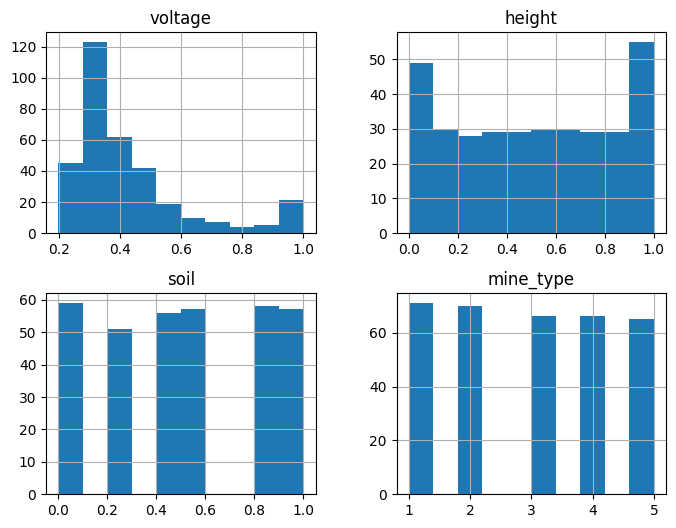

Best k: 2


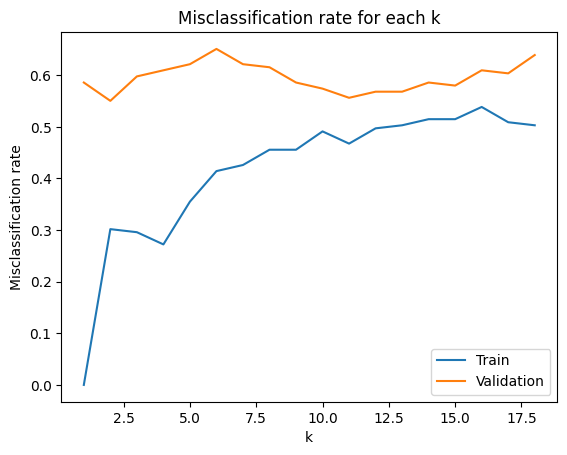

Predicted   1   2   3  4  5
Actual                     
1          21   1   6  4  2
2           0  33   2  3  0
3           5   5  10  6  4
4          13   5  10  9  1
5          10   1   8  7  3 



In [44]:
# Your Phase 2 solution to the problem goes here.
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt

# Step 1: Loading data, performing EDA, and summarizing target label and features
df = pd.read_csv('data/land_mines.csv')
print(df.shape, '\n')
print(df.dtypes, '\n')
print(df.head(n=15).to_string(), '\n')
print(df.describe().to_string(), '\n')

print(df['mine_type'].value_counts().sort_index())
print(df.groupby('mine_type')[['voltage','height','soil']].agg(['mean','std']))
df.hist(figsize=(8,6))
plt.show()

# Step 2: Split data into training and testing
eval_X_raw = df[['voltage', 'height', 'soil']]
eval_y = df['mine_type']

(
    eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid
) = sklearn.model_selection.train_test_split(
    eval_X_raw, eval_y, test_size = 0.5, random_state = 65)
eval_scaler = sklearn.preprocessing.MinMaxScaler()
# scales the training and validation data to be between 0 and 1
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)

# Step 3: Build a knn classifier
eval_ks = np.arange(1, 19)
eval_valid_error = []
eval_train_error = []

for eval_k in eval_ks:
    eval_candidate = sklearn.neighbors.KNeighborsClassifier(n_neighbors = int(eval_k))
    eval_candidate.fit(eval_X_train_scaled, eval_y_train)
    eval_valid_hat = eval_candidate.predict(eval_X_valid_scaled)
    eval_train_hat = eval_candidate.predict(eval_X_train_scaled)
    # compute the mean error for the validation and training sets
    eval_valid_error.append(np.mean(eval_y_valid.to_numpy() != eval_valid_hat))
    eval_train_error.append(np.mean(eval_y_train.to_numpy() != eval_train_hat))
eval_k_star = int(eval_ks[np.argmin(eval_valid_error)])
print("Best k:", eval_k_star)
# print misclassification rate for training and validation sets for each k
plt.plot(eval_ks, eval_train_error, label='Train')
plt.plot(eval_ks, eval_valid_error, label='Validation')
plt.xlabel('k') 
plt.ylabel('Misclassification rate')
plt.legend()
plt.title('Misclassification rate for each k')
plt.show()

# Step 4: Print a confusion table
eval_best = sklearn.neighbors.KNeighborsClassifier(n_neighbors = eval_k_star)
eval_best.fit(eval_X_train_scaled, eval_y_train)
eval_valid_hat = eval_best.predict(eval_X_valid_scaled)


# eval_confusion_table = sklearn.metrics.confusion_matrix(
#     eval_y_valid, eval_valid_hat)

eval_confusion_table = pd.crosstab(eval_y_valid, eval_valid_hat, rownames=['Actual'], colnames=['Predicted'])
print(eval_confusion_table, '\n')


The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
- Done. See code above
- This dataset consists of 338 rows and 4 columns. The voltage, height, and soil variables are all floats (decimals), while the mine type is an integer. However, this should not be treated as a numerical output, since a number is just used to *classify* the mine type. The voltage, height, and soil variables range in value from 0-1 and the mine type is an integer from 1-5. Additionally, all variables are fairly distributed, except for voltage, which is very right-skewed.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
- Done. See code above
3. Build a $k$-NN classifier. Explain how you select $k$.
- Done. See code above
- I began by limiting the range of k-values from 1 to the square root of the number of rows in the CSV, which was around 18.5. I then looped through all values of k and calculated the misclassification rate. The best k-value with this approach is the one that minimizes the mean number of incorrect classifications in the validation set, which happens to be k=2 with a misclassification rate of 55%.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
- Done. See code above
- The overall accuracy of the model is 76/169, or 45%. The model has the following accuracies: 61.8% mine types 1 classified correctly, 86.8% of mine type 2, 33.3% of mine type 3, 23.7% for mine type 4, and only 10.3% correct for mine type 5. The model is most accurate with mine types 1 and 2, and gets progressively less effective with the other mine types.
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.
- I would advise the users to consider how the model is heavily biased towards type 1 mines by often misclassifying types 4-5 as type 1 or 3. If type 1 is more dangerous than type 4 or 5 or requires more caution, this is ok, since it will overpredict the amount of safety needed. However, if type 4 or 5 mines are more dangerous than type 1, for example, this model should not be used to advise on mine spotting or removal techniques. This is because it may classify a mine as less dangerous than it actually is, which risks human lives. We must add some context and color through human judgement before deciding how much to rely on a prediction model to make decisions.

### *Reflection on AI assistance
In your own words without generative AI. In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.
- Main improvements: The AI model is best at comparing my work with the rubric to see where I missed information. For example, I didn't realize I had to describe my EDA until I checked with Claude. It is also good at identifying factual inaccuracies in my written responses.
- AI mistakes/limitations: I did not run into any AI mistakes for this assignment. To limit mistakes, it's important to provide the AI with enough context about the assignment (rubric, code, specific prompts).
- Verifcation: To verify the AI suggestions, I went through each individual suggestion and cross-checked it with the internet for accuracy or the rubric for relevancy. I also thought of it in the broader scope of my code to see if it made sense to add.
- Remaining concerns: I do not have remaining concerns, since I gave the AI enough context to understand my assignment and also validated outputs, including rejecting one suggestion because it was out of scope.